# Benchmark grid — model comparison across the test problems

The 4 defined mixed-variable test problems × 4 surrogate models (Standard LVGP, Heteroscedastic LVGP,
Separate GP, Categorical-kernel GP), all sharing the same SLHD initial design, acquisitions and sweep.
Reads `results/<function>/<model>/<acq>/nrep<NN>/seed<NN>.{npz,mat}` (python + matlab engines).

This generalizes the single-problem plots from `previous_ver/compare_methods.ipynb`: every view below is
**faceted over the test problems**, so it works for 1 or for all of them as the sweep fills in.

**Kernel: ml_gp_env.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.results import (GridResults, facet, heatmaps_by_function, final_regret_table,
                           coverage, runtime_table)

grid = GridResults.load('../results')
print('functions:', grid.functions())
print('models   :', grid.models())
print('cells    :', len(grid.runs))

functions: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']
models   : ['categorical_kernel', 'heter_LVGP', 'separate_gp', 'standard_LVGP']
cells    : 4554


## The toggles

`GROUND_TRUTH` — how the **incumbent** (the "best design so far") is chosen, and what σ² means:

| | `True` | `False` |
|---|---|---|
| incumbent | argmin of the **noise-free** f | argmin of the **observed** replicate mean |
| σ² | the **true** noise variance σ(x,ℓ)² there | the **sample** variance of the replicates there |

This matters. The observed mean can dip *below* the true optimum f\* purely from noise (on branin,
`noisy_best = −3.16` against `f* = 0.465`), which makes a noisy "regret" look negative. `GROUND_TRUTH = True`
is the honest convergence measure; `False` shows what the optimizer actually saw.

`LOG_SCALE` applies to the regret and σ² convergence panels (not the value plot, which needs a linear axis
to show the f\* line).

In [2]:
GROUND_TRUTH = True         # <-- incumbent & sigma^2 by the noise-free f (see table above)
LOG_SCALE    = True         # <-- log y-axis on the regret / sigma^2 convergence panels
ACF, PARAM   = 'ei', float('nan')
N_REP        = 10           # replicates per design point: the sweep runs 3 and 10
FUNCS        = grid.functions()          # or e.g. ['branin_hetero', 'ackley_2d']
print(f'{len(FUNCS)} problems: {FUNCS}')

4 problems: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']


## What the plots are averaging over
The sweep is long-running, so check the seed count behind each curve before reading too much into it.
`0` means that cell has not been computed yet.

In [3]:
coverage(grid, n_rep=N_REP)

model                       Categorical kernel  Heteroscedastic LVGP  \
function      acq                                                      
ackley_2d     ANPEI(β=0.8)                  30                     0   
              EI                            30                     0   
              HAEI(γ=0.5)                   30                     0   
              LCB                           30                     0   
              PI                            30                     0   
              RAHBO(α=0.5)                  30                     0   
branin_hetero ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
griewank_2d   ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
sixhump_camel ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   

model                       Separate GP  Standard LVGP  
function      acq                                       
ackley_2d     ANPEI(β=0.8)           30              0  
              EI                     30              0  
              HAEI(γ=0.5)            30              0  
              LCB                    30             24  
              PI                     30              0  
              RAHBO(α=0.5)           30              0  
branin_hetero ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
griewank_2d   ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
sixhump_camel ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0

## Convergence — REGRET (value − f\*)
One panel per problem, the 4 models overlaid: mean ± standard error over seeds. Lower is better.
With `GROUND_TRUTH = True` regret is guaranteed ≥ 0, so the log axis is meaningful.

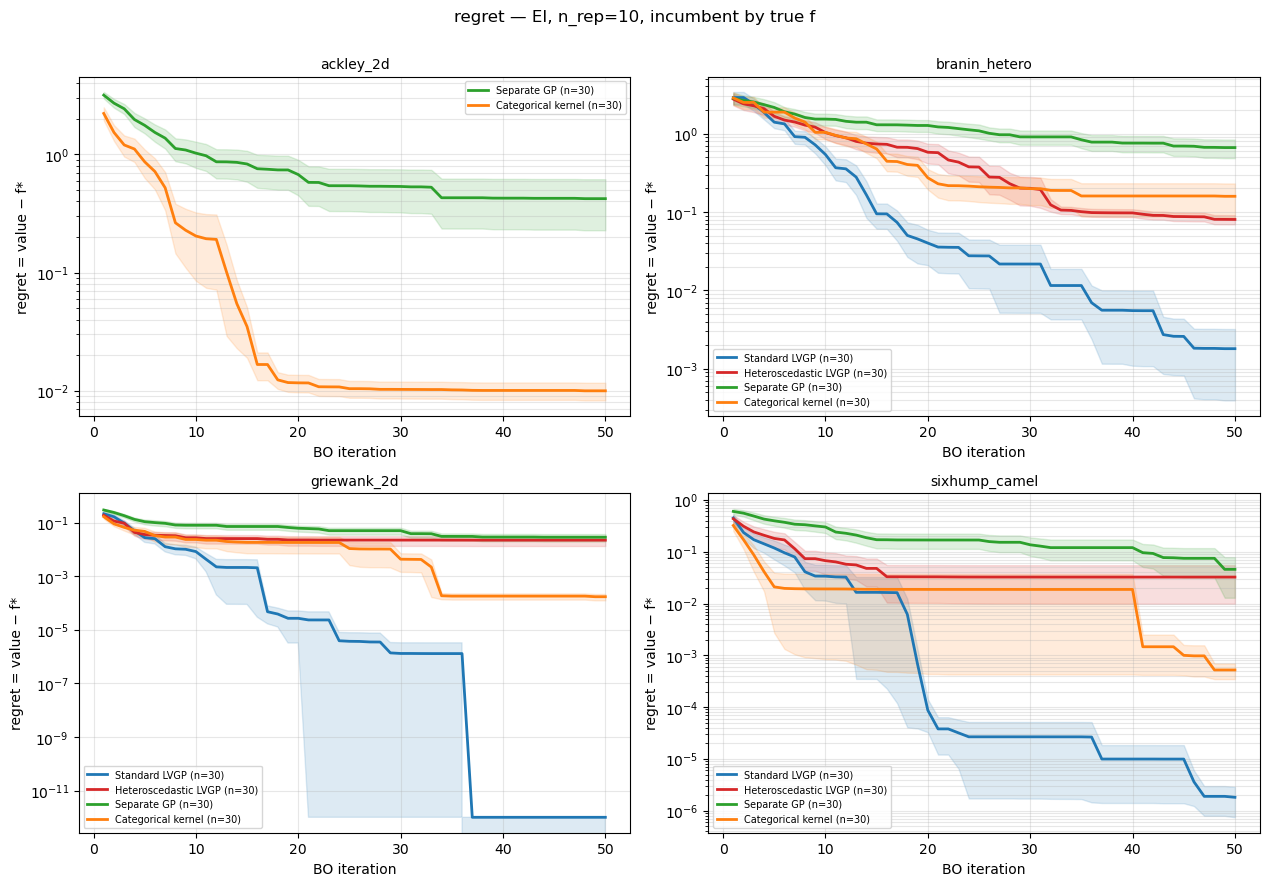

In [4]:
facet(grid, 'regret', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE);

## Convergence — VALUE, with the true optimum f\* as a horizontal line
The same runs on a linear axis, showing how close each model's best design gets to f\* (dashed grey).

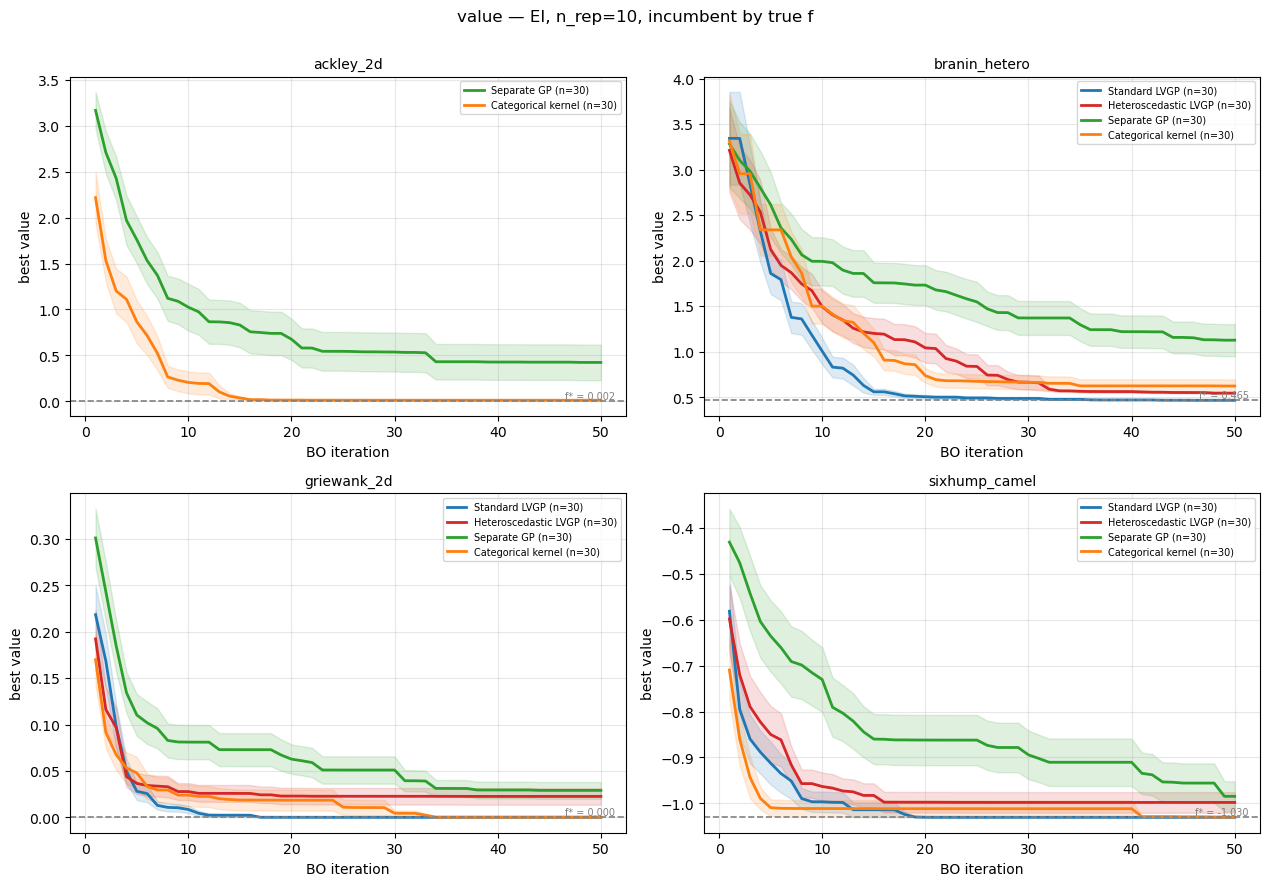

In [5]:
facet(grid, 'value', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=False);

## Noise variance σ² at the incumbent best design
The heteroscedastic question: *does the model end up recommending a design that sits in a noisy region?*
A noise-aware model should settle on a **lower σ²** incumbent, all else equal. With `GROUND_TRUTH = True`
this is the true σ(x,ℓ)² at the incumbent — not an estimate.

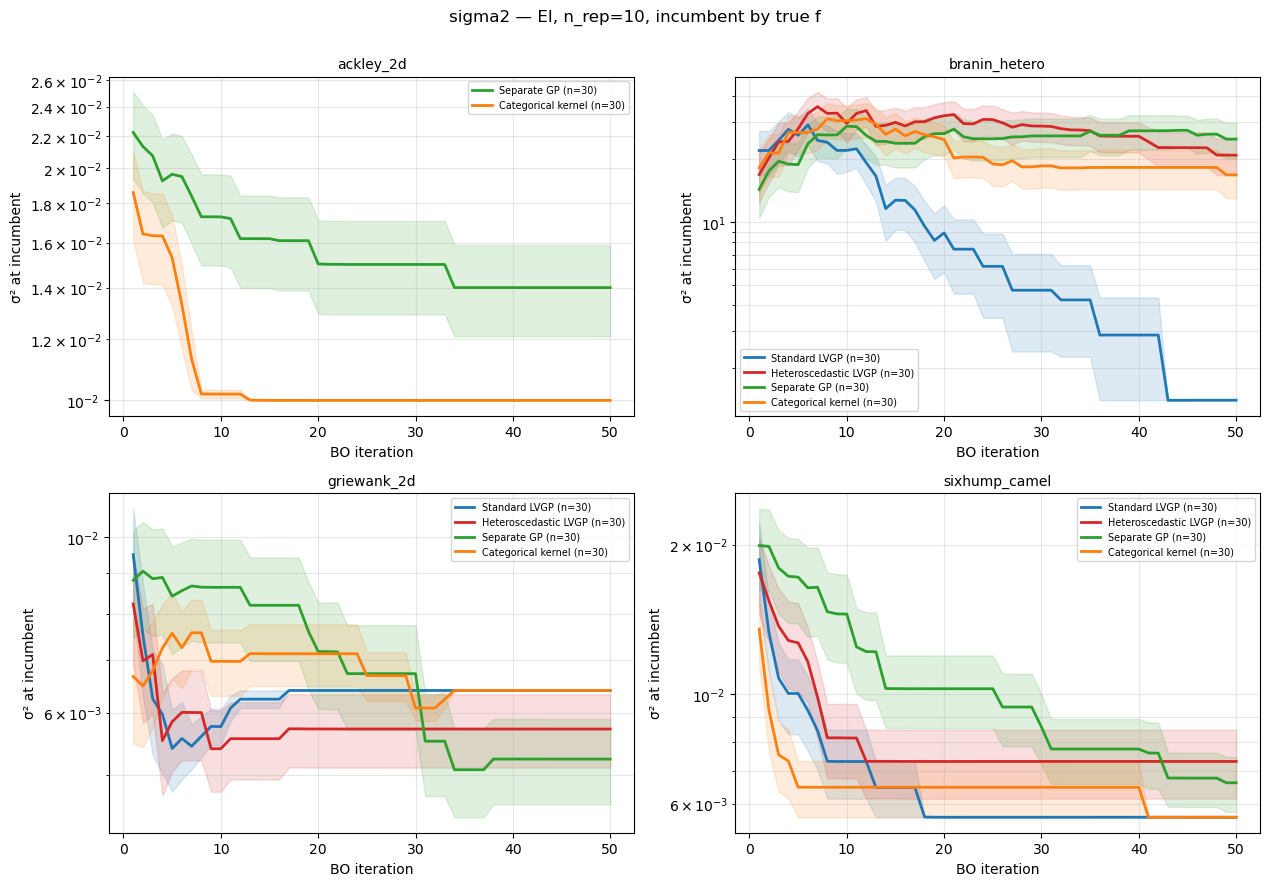

In [6]:
facet(grid, 'sigma2', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE);

## Summary heatmaps — acquisition × model, one per problem
Final regret for every acquisition actually present in the results. Acquisition rows with no data anywhere
are dropped, so there are no blank bands. Darker = better (lower regret).

Note `standard_LVGP` only supports the noise-blind acquisitions (ei/lcb/pi) by construction, so its
haei/anpei/rahbo entries are legitimately empty.

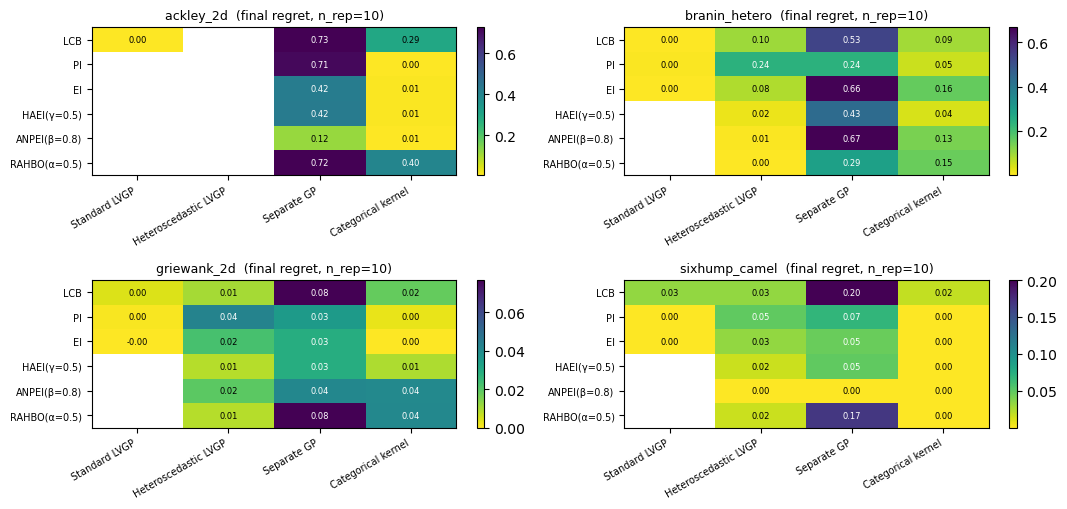

In [7]:
heatmaps_by_function(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH);

## Final-regret summary table (problem × model)

In [8]:
final_regret_table(grid, acf=ACF, param=PARAM, n_rep=N_REP)

,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
ackley_2d,0.010 ± 0.009,None,0.422 ± 1.044,None
branin_hetero,0.158 ± 0.390,0.080 ± 0.058,0.662 ± 0.950,0.002 ± 0.008
griewank_2d,0.000 ± 0.000,0.023 ± 0.048,0.029 ± 0.049,-0.000 ± 0.000
sixhump_camel,0.001 ± 0.001,0.032 ± 0.121,0.046 ± 0.177,0.000 ± 0.000


## Cost — mean wall-clock seconds per cell
The two MATLAB LVGP models dominate the sweep's runtime; the python GPs are an order of magnitude cheaper.

model,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
function,,,,
ackley_2d,73.4,NaN,18.8,393.9
branin_hetero,113.8,750.3,44.5,676.4
griewank_2d,54.2,312.7,17.7,312.6
sixhump_camel,58.2,312.9,20.5,305.3


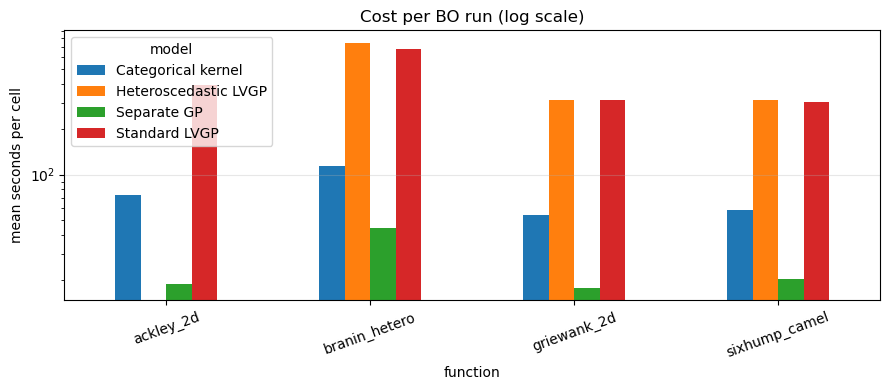

In [9]:
rt = runtime_table(grid)
display(rt)
ax = rt.plot(kind='bar', figsize=(9, 4), rot=20)
ax.set_ylabel('mean seconds per cell'); ax.set_yscale('log')
ax.set_title('Cost per BO run (log scale)'); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()

## Reading these plots

- **Regret vs σ²** are the two axes of the heteroscedastic trade-off. A model can win on regret while
  parking the incumbent in a high-noise region (bad if you must *deploy* that design), or vice versa.
- **`standard_LVGP` is noise-blind**: it never sees the replicate variance, so any advantage it shows on a
  noise-blind acquisition (ei/lcb/pi) is a fair comparison, but it cannot run haei/anpei/rahbo at all.
- Flip **`GROUND_TRUTH = False`** to see the optimizer's own view. Regret can go negative there — that is
  the noise, not a bug.
- Change `N_REP` between 3 and 10 to see how replicate count changes the variance estimate each model works
  from — the whole point of the heteroscedastic setup.